## Classification of Text Documents using Naive Bayes

In **Natural Language Processing (NLP)** and machine learning, **Naive Bayes** is a popular method for classifying text documents. It uses **Bayes' Theorem** to compute the probability of a document belonging to a particular category based on the words (features) it contains.

### Problem Statement
A text classification model that assigns one of four topic labels to short text sentences:
- Technology
- Sports
- Politics
- Entertainment

### How we proceed:
1. Import Libraries
2. Load the Dataset
3. Split Data into Train/Test Sets
4. Convert Text to Numerical Features (CountVectorizer)
5. Train a Multinomial Naive Bayes Classifier
6. Make Predictions
7. Evaluate the Model (Accuracy + Confusion Matrix)
8. Predict on Unseen Data


Important Terminologies:

- **CountVectorizer** - converts raw text into a matrix of word counts (Bag of Words)
- **MultinomialNB** - the Naive Bayes variant suited for discrete feature counts (like word frequencies)
- **accuracy_score / confusion_matrix** - to evaluate model performance
- **matplotlib / seaborn** - for plotting the confusion matrix heatmap

### Step 1 - Importing Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


---
### Step 2 - Loading the Dataset

The dataset contains short sentences labelled into one of four categories: **Technology**, **Sports**, **Politics**, and **Entertainment**.


In [30]:
# Load the dataset
data = pd.read_csv('synthetic_text_data.csv')

# Separate features and labels
X = data['text']
y = data['label']

print(f"Dataset shape: {data.shape}")
print(f"\nLabel distribution:\n{y.value_counts()}")
print(f"\nFirst 5 rows:")
data.head()

Dataset shape: (85, 2)

Label distribution:
label
Technology       30
Politics         21
Entertainment    19
Sports           15
Name: count, dtype: int64

First 5 rows:


,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


---
### Step 3 - Splitting the Data

We split the dataset into:
- **Training set (80%)** — used to train (fit) the model
- **Testing set (20%)** — used to evaluate the model on unseen data

NOTE: `random_state=42` ensures the split is reproducible — you get the same split every time you run the code.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 68
Testing  samples : 17


---
### Step 4 - Text Preprocessing: Converting Text to Numeric Features i.e. Vectors

We use **CountVectorizer** (Bag of Words approach):
- It builds a vocabulary of all unique words across the training corpus.
- Each sentence is represented as a vector of word counts.


`fit_transform(X_train)` - Learns vocabulary from training data **and** transforms it 

`transform(X_test)` - Applies the **same** learned vocabulary to test data (no re-learning) 


NOTE: We must **never** call `fit_transform` on the test set — that would cause **data leakage**.

In [32]:
vectorizer = CountVectorizer()

# Fit on training data and transform it
X_train_vectorized = vectorizer.fit_transform(X_train)

# Only transform the test data (use the vocabulary learned from training)
X_test_vectorized = vectorizer.transform(X_test)

print(f"Vocabulary size       : {len(vectorizer.vocabulary_)} unique words")
print(f"Training matrix shape : {X_train_vectorized.shape}")
print(f"Testing  matrix shape : {X_test_vectorized.shape}")

Vocabulary size       : 395 unique words
Training matrix shape : (68, 395)
Testing  matrix shape : (17, 395)


---
### Step 5 - Training the Multinomial Naive Bayes Classifier

**Multinomial Naive Bayes** is the go-to Naive Bayes variant for text classification because:
- It is designed for **discrete** (count-based) features — exactly what word counts are.
- It estimates the probability of each word given each class (category) from the training data.
- At prediction time, it combines these word probabilities (using Bayes' Theorem) to assign the most likely class.

Training is a single call to `.fit()`:

In [33]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

print("Model trained successfully!")
print(f"Classes learned: {model.classes_}")

Model trained successfully!
Classes learned: ['Entertainment' 'Politics' 'Sports' 'Technology']


---
### Step 6 - Making Predictions

Now we use the trained model to predict the category label for each sentence in the **test set**.

The vectorized test data (`X_test_vectorized`) is passed through the model, which assigns the most probable class label to each sample.

In [34]:
y_pred = model.predict(X_test_vectorized)

# Preview a few predictions vs actual labels
comparison = pd.DataFrame({
    'Text'      : X_test.values,
    'Actual'    : y_test.values,
    'Predicted' : y_pred
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']

print("Sample predictions:")
comparison.head(10)

Sample predictions:


,Text,Actual,Predicted,Correct
0,National debates on the legalization of mariju...,Politics,Politics,True
1,Artificial intelligence is advancing in health...,Technology,Technology,True
2,"Self-driving cars are becoming a reality, with...",Technology,Technology,True
3,The debate on free speech continues to be a ho...,Politics,Politics,True
4,Video game developers are excited about the re...,Entertainment,Entertainment,True
5,Television networks are trying to adapt to the...,Entertainment,Entertainment,True
6,Cybersecurity threats are increasing as hacker...,Technology,Technology,True
7,Baseball teams are preparing for the playoffs ...,Sports,Sports,True
8,Quantum computing promises to revolutionize in...,Technology,Technology,True
9,Political leaders are pledging to increase fun...,Politics,Politics,True



### Step 7 - Evaluating the Model
Accuracy Score
Accuracy is the percentage of test samples correctly classified.
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} \times 100$$

Confusion Matrix
A confusion matrix shows a breakdown of correct and incorrect predictions for each class:
- Rows → True (actual) labels
- Columns → Predicted labels
- Diagonal → Correct predictions
- Off-diagonal → Misclassifications

Accuracy: 88.24%


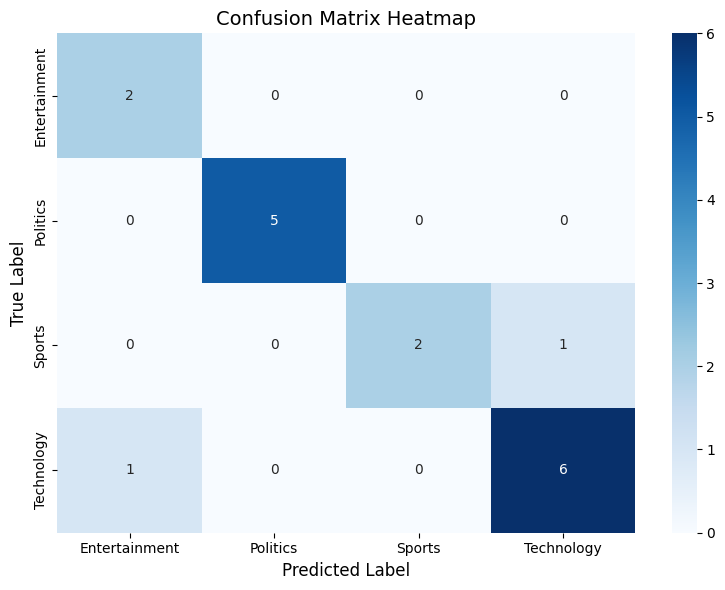

In [35]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation

- The model achieves approximately **88% accuracy**, meaning it correctly predicts the category for roughly 88 out of every 100 test samples.
- The **confusion matrix heatmap** uses darker blue shades for higher counts — the strong diagonal indicates most samples are correctly classified.
- Any off-diagonal values reveal which categories the model occasionally confuses with each other.

### Step 8 — Predicting on Unseen Data

Let's test the model on a brand-new sentence it has **never seen** during training.

The process is:
1. Take the raw text string.
2. **Transform** it using the already-fitted `vectorizer` (do not re-fit!).
3. Pass the vector to the model's `.predict()` method.
4. Print the predicted category.

In [36]:
# Example 1 — Technology-related sentence (from the article)
user_input = "I love artificial intelligence and machine learning"

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)

print(f"Input   : '{user_input}'")
print(f"Category: '{predicted_label[0]}'")

Input   : 'I love artificial intelligence and machine learning'
Category: 'Technology'


In [37]:
# Try your own sentences — change the list below!
custom_sentences = [
    "The president signed a new trade agreement today",
    "The team scored three goals in the final match",
    "The new blockbuster movie broke box office records",
    "Quantum computing will revolutionize data encryption"
]

custom_vectorized = vectorizer.transform(custom_sentences)
custom_predictions = model.predict(custom_vectorized)

print("Predictions on custom sentences:\n")
for sentence, label in zip(custom_sentences, custom_predictions):
    print(f"  [{label:>15}]  {sentence}")

Predictions on custom sentences:

  [     Technology]  The president signed a new trade agreement today
  [       Politics]  The team scored three goals in the final match
  [  Entertainment]  The new blockbuster movie broke box office records
  [     Technology]  Quantum computing will revolutionize data encryption


### Key Takeaways
- **Naive Bayes** is fast, simple, and surprisingly effective for text classification tasks.
- **CountVectorizer** (Bag of Words) is a straightforward but powerful way to represent text numerically.
- The model correctly categorises Technology, Sports, Politics, and Entertainment text with ~88% accuracy on this dataset.
- For even better performance, you could explore **TF-IDF vectorization**, **stop word removal**, or more advanced models like Logistic Regression or BERT.